In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("Trade Journal Analyser ready")

Trade Journal Analyser ready


In [3]:
# Trade journal structure
# You'll enter your real trades here
# For now we build the framework with sample data
# Replace with your actual trades

trades_data = [
    # date, pair, direction, entry, sl, tp, exit_price, outcome
    # outcome: 'WIN' or 'LOSS' or 'BE' (breakeven)
    # Replace these with your real trades
    {"date": "2024-01-02", "pair": "XAUUSD", "direction": "LONG",
     "entry": 2063.5, "sl": 2055.0, "tp": 2080.0,
     "exit_price": 2078.0, "outcome": "WIN", "session": "London",
     "setup": "SMC", "notes": "BOS + OB retest"},

    {"date": "2024-01-03", "pair": "XAUUSD", "direction": "SHORT",
     "entry": 2082.0, "sl": 2090.0, "tp": 2062.0,
     "exit_price": 2090.0, "outcome": "LOSS", "session": "NY",
     "setup": "SMC", "notes": "Stop hunted"},

    {"date": "2024-01-04", "pair": "GBPUSD", "direction": "LONG",
     "entry": 1.2715, "sl": 1.2685, "tp": 1.2775,
     "exit_price": 1.2775, "outcome": "WIN", "session": "London",
     "setup": "Lipschutz", "notes": "HTF bias confirmed"},

    {"date": "2024-01-08", "pair": "XAUUSD", "direction": "LONG",
     "entry": 2030.0, "sl": 2020.0, "tp": 2055.0,
     "exit_price": 2020.0, "outcome": "LOSS", "session": "Asian",
     "setup": "SMC", "notes": "Asian range break failed"},

    {"date": "2024-01-09", "pair": "GBPJPY", "direction": "SHORT",
     "entry": 183.50, "sl": 184.20, "tp": 182.10,
     "exit_price": 182.10, "outcome": "WIN", "session": "London",
     "setup": "SMC", "notes": "Supply zone rejection"},
]

# Convert to DataFrame
df = pd.DataFrame(trades_data)
df['date'] = pd.to_datetime(df['date'])

# Calculate R-multiples automatically
df['risk_pips']   = abs(df['entry'] - df['sl'])
df['reward_pips'] = abs(df['tp']    - df['entry'])
df['rr_ratio']    = df['reward_pips'] / df['risk_pips']

# Actual R achieved
df['actual_r'] = np.where(
    df['outcome'] == 'WIN',
    abs(df['exit_price'] - df['entry']) / df['risk_pips'],
    np.where(
        df['outcome'] == 'LOSS',
        -abs(df['exit_price'] - df['entry']) / df['risk_pips'],
        0  # breakeven
    )
)

print("Sample trade journal loaded")
print(f"Total trades: {len(df)}")
print(f"\n{df[['date','pair','direction','rr_ratio','actual_r','outcome']].to_string(index=False)}")

Sample trade journal loaded
Total trades: 5

      date   pair direction  rr_ratio  actual_r outcome
2024-01-02 XAUUSD      LONG  1.941176  1.705882     WIN
2024-01-03 XAUUSD     SHORT  2.500000 -1.000000    LOSS
2024-01-04 GBPUSD      LONG  2.000000  2.000000     WIN
2024-01-08 XAUUSD      LONG  2.500000 -1.000000    LOSS
2024-01-09 GBPJPY     SHORT  2.000000  2.000000     WIN


In [4]:
def analyse_journal(df):
    """
    Complete trade journal analysis.
    Prints all key metrics a quant trader needs.
    """
    total    = len(df)
    wins     = (df['outcome']=='WIN').sum()
    losses   = (df['outcome']=='LOSS').sum()
    be       = (df['outcome']=='BE').sum()
    win_rate = wins / total

    avg_win  = df[df['outcome']=='WIN']['actual_r'].mean()
    avg_loss = df[df['outcome']=='LOSS']['actual_r'].mean()
    avg_rr   = df['rr_ratio'].mean()
    expectancy = (win_rate * avg_win) + \
                 ((1-win_rate) * abs(avg_loss))

    # Cumulative R curve
    df_sorted = df.sort_values('date').copy()
    df_sorted['cumulative_r'] = df_sorted['actual_r'].cumsum()

    # Max drawdown in R
    cum_r = df_sorted['cumulative_r']
    dd_r  = (cum_r - cum_r.cummax()).min()

    print(f"\n{'='*55}")
    print(f"  TRADE JOURNAL ANALYSIS")
    print(f"{'='*55}")
    print(f"  Total trades     : {total}")
    print(f"  Wins/Losses/BE   : {wins}/{losses}/{be}")
    print(f"  Win rate         : {win_rate:.1%}")
    print(f"  Avg planned RR   : {avg_rr:.2f}")
    print(f"  Avg win (R)      : +{avg_win:.2f}R")
    print(f"  Avg loss (R)     : {avg_loss:.2f}R")
    print(f"  Expectancy       : {expectancy:.3f}R per trade")
    print(f"  Max DD (R)       : {dd_r:.2f}R")
    print(f"  Total R earned   : {df_sorted['actual_r'].sum():.2f}R")
    print(f"{'='*55}")

    # Breakdown by pair
    print(f"\n  BY PAIR:")
    print(f"  {'-'*45}")
    for pair in df['pair'].unique():
        p = df[df['pair']==pair]
        wr = (p['outcome']=='WIN').mean()
        er = p['actual_r'].mean()
        print(f"  {pair:<10} Trades:{len(p):>3}  "
              f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    # Breakdown by session
    if 'session' in df.columns:
        print(f"\n  BY SESSION:")
        print(f"  {'-'*45}")
        for sess in df['session'].unique():
            s = df[df['session']==sess]
            wr = (s['outcome']=='WIN').mean()
            er = s['actual_r'].mean()
            print(f"  {sess:<10} Trades:{len(s):>3}  "
                  f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    # Breakdown by setup
    if 'setup' in df.columns:
        print(f"\n  BY SETUP:")
        print(f"  {'-'*45}")
        for setup in df['setup'].unique():
            s = df[df['setup']==setup]
            wr = (s['outcome']=='WIN').mean()
            er = s['actual_r'].mean()
            print(f"  {setup:<12} Trades:{len(s):>3}  "
                  f"WR:{wr:.0%}  Avg R:{er:>+.2f}")

    return df_sorted

df_analysed = analyse_journal(df)


  TRADE JOURNAL ANALYSIS
  Total trades     : 5
  Wins/Losses/BE   : 3/2/0
  Win rate         : 60.0%
  Avg planned RR   : 2.19
  Avg win (R)      : +1.90R
  Avg loss (R)     : -1.00R
  Expectancy       : 1.541R per trade
  Max DD (R)       : -1.00R
  Total R earned   : 3.71R

  BY PAIR:
  ---------------------------------------------
  XAUUSD     Trades:  3  WR:33%  Avg R:-0.10
  GBPUSD     Trades:  1  WR:100%  Avg R:+2.00
  GBPJPY     Trades:  1  WR:100%  Avg R:+2.00

  BY SESSION:
  ---------------------------------------------
  London     Trades:  3  WR:100%  Avg R:+1.90
  NY         Trades:  1  WR:0%  Avg R:-1.00
  Asian      Trades:  1  WR:0%  Avg R:-1.00

  BY SETUP:
  ---------------------------------------------
  SMC          Trades:  4  WR:50%  Avg R:+0.43
  Lipschutz    Trades:  1  WR:100%  Avg R:+2.00


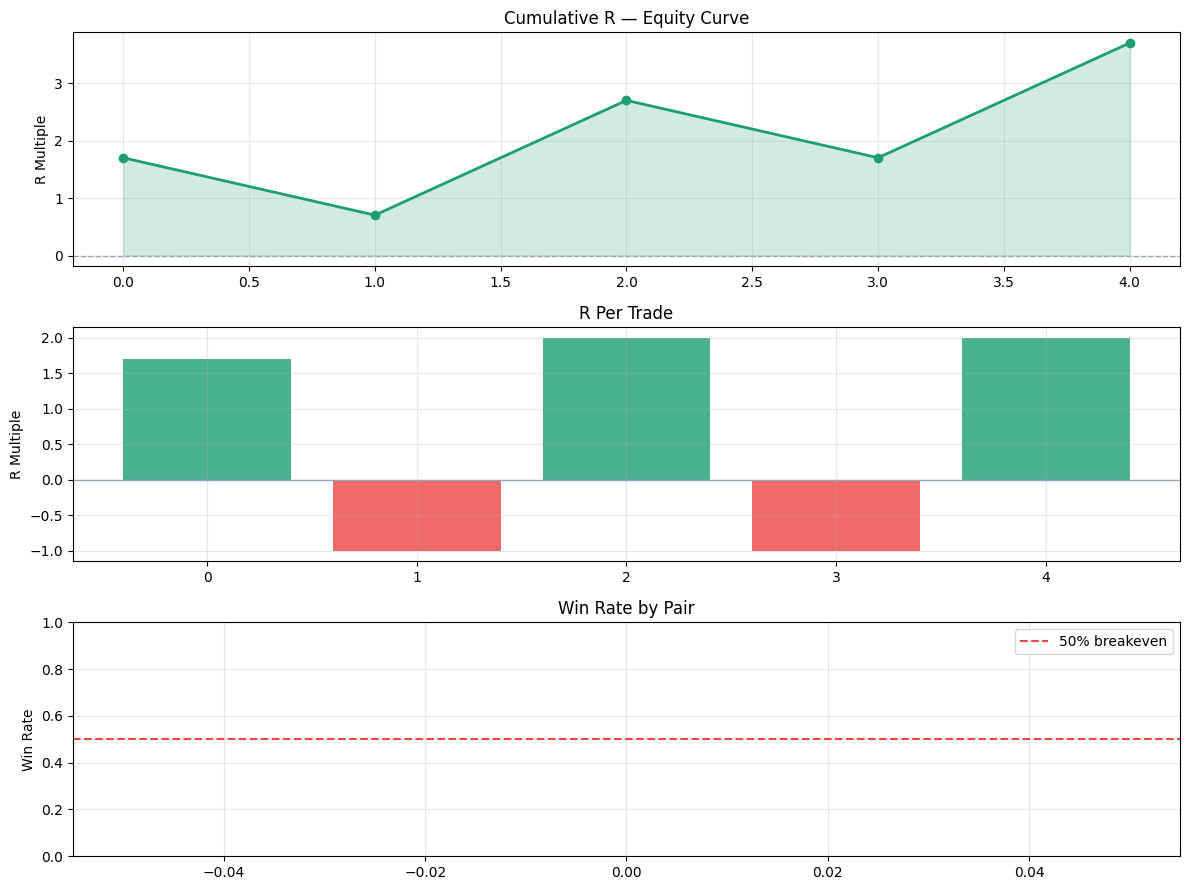

In [7]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9))

# Panel 1: Cumulative R curve
ax1.plot(range(len(df_analysed)),
         df_analysed['cumulative_r'],
         color='#1D9E75', lw=2, marker='o', markersize=6)
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.fill_between(range(len(df_analysed)),
                  df_analysed['cumulative_r'], 0,
                  where=(df_analysed['cumulative_r']>=0),
                  alpha=0.2, color='#1D9E75')
ax1.fill_between(range(len(df_analysed)),
                  df_analysed['cumulative_r'], 0,
                  where=(df_analysed['cumulative_r']<0),
                  alpha=0.2, color='#ef4444')
ax1.set_title('Cumulative R — Equity Curve')
ax1.set_ylabel('R Multiple')
ax1.grid(True, alpha=0.3)

# Panel 2: R per trade bar chart
colors_bar = ['#1D9E75' if r > 0 else '#ef4444'
               for r in df_analysed['actual_r']]
ax2.bar(range(len(df_analysed)),
        df_analysed['actual_r'],
        color=colors_bar, alpha=0.8)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.set_title('R Per Trade')
ax2.set_ylabel('R Multiple')
ax2.grid(True, alpha=0.3)

# Panel 3: Win rate by pair
pairs    = df['pair'].unique()
wr_pairs = [((df[df['pair']==p]['outcome']=='WIN').mean())
             for p in pairs]
ax3.bar(pairs, wr_pairs, color='#2563eb', alpha=0.8)
ax3.axhline(0.5, color='#ef4444', lw=1.5,
            linestyle='--', label='50% breakeven')
ax3.set_title('Win Rate by Pair')
ax3.set_ylabel('Win Rate')
ax3.set_ylim(0, 1)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Clear sample data and start with real trades
df = pd.DataFrame(columns=['date','pair','direction','entry',
                             'sl','tp','exit_price','outcome',
                             'session','setup','notes',
                             'risk_pips','reward_pips',
                             'rr_ratio','actual_r'])

df = add_trade(df, "2026-07-02", "XAUUSD", "LONG",
               4073.17, 4046.97, 4131.70, 4182.47, "WIN",  "Tokyo",    "SMC", "")
df = add_trade(df, "2026-07-01", "XAUUSD", "SHORT",
               4013.02, 4035.51, 3960.54, 3960.54, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-29", "XAUUSD", "SHORT",
               4031.33, 4074.75, 3972.48, 3972.48, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-26", "XAUUSD", "LONG",
               4090.06, 4045.21, 4147.94, 4045.21, "LOSS", "NY",       "SMC", "")
df = add_trade(df, "2026-06-26", "XAUUSD", "SHORT",
               4004.19, 4028.52, 3938.55, 4028.52, "LOSS", "Tokyo",    "SMC", "")
df = add_trade(df, "2026-06-24", "XAUUSD", "SHORT",
               4055.45, 4085.88, 3978.71, 3978.71, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-23", "XAUUSD", "SHORT",
               4104.02, 4132.50, 4033.45, 4018.09, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-23", "XAUUSD", "SHORT",
               4160.98, 4216.54, 4087.90, 4087.90, "WIN",  "Tokyo",    "SMC", "")
df = add_trade(df, "2026-06-18", "XAUUSD", "SHORT",
               4266.46, 4316.42, 4171.98, 4171.98, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-16", "XAUUSD", "LONG",
               4346.56, 4316.71, 4409.61, 4316.71, "LOSS", "London",   "SMC", "")
df = add_trade(df, "2026-06-15", "XAUUSD", "LONG",
               4285.53, 4207.56, 4400.49, 4207.56, "LOSS", "Sydney",   "SMC", "")
df = add_trade(df, "2026-06-10", "XAUUSD", "SHORT",
               4146.80, 4198.67, 4047.17, 4047.17, "WIN",  "London",   "SMC", "")
df = add_trade(df, "2026-06-09", "XAUUSD", "SHORT",
               4300.25, 4353.60, 4220.56, 4220.56, "WIN",  "NY",       "SMC", "")
df = add_trade(df, "2026-06-09", "XAUUSD", "SHORT",
               4326.41, 4353.60, 4258.56, 4353.60, "LOSS", "London",   "SMC", "")
df = add_trade(df, "2026-06-05", "XAUUSD", "SHORT",
               4461.43, 4490.10, 4396.79, 4330.70, "WIN",  "Sydney",   "SMC", "")
df = add_trade(df, "2026-06-03", "XAUUSD", "SHORT",
               4438.73, 4465.61, 4368.90, 4465.61, "LOSS", "NY",       "SMC", "")

# Run the full analysis
df_analysed = analyse_journal(df)

NameError: name 'add_trade' is not defined

In [1]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 10))

df_sorted = df.sort_values('date').copy()
df_sorted['cumulative_r'] = df_sorted['actual_r'].astype(float).cumsum()
cum_r = df_sorted['cumulative_r'].astype(float).values
act_r = df_sorted['actual_r'].astype(float).values
x_idx = np.arange(len(df_sorted), dtype=float)

# Panel 1: Cumulative R
ax1.plot(x_idx, cum_r, color='#1D9E75', lw=2,
         marker='o', markersize=6)
ax1.axhline(0, color='#94a3b8', lw=1, linestyle='--')
ax1.fill_between(x_idx, cum_r, 0,
                  where=(cum_r >= 0),
                  alpha=0.2, color='#1D9E75')
ax1.plot(x_idx, 1.911 * x_idx, color='#2563eb',
         lw=1.5, linestyle='--',
         label='Expected (1.91R/trade)')
ax1.set_title('XAU/USD — Cumulative R (16 Real Trades)')
ax1.set_ylabel('Cumulative R')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Panel 2: Individual R bars
colors_bar = ['#1D9E75' if r > 0 else '#ef4444' for r in act_r]
bars = ax2.bar(x_idx, act_r, color=colors_bar, alpha=0.85)
ax2.axhline(0, color='#94a3b8', lw=1)
ax2.axhline(float(act_r.mean()), color='#2563eb', lw=1.5,
            linestyle='--',
            label=f"Avg: +{act_r.mean():.2f}R")
ax2.set_title('R Per Trade')
ax2.set_ylabel('R Multiple')
ax2.legend()
ax2.grid(True, alpha=0.3)
for bar, r in zip(bars, act_r):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05 if r > 0
             else bar.get_height() - 0.15,
             f'{r:+.1f}', ha='center',
             fontsize=8, color='#374151')

# Panel 3: Session performance
sessions   = df['session'].unique()
sess_wr    = [(df[df['session']==s]['outcome']=='WIN').mean()
               for s in sessions]
sess_avgr  = [float(df[df['session']==s]['actual_r'].astype(float).mean())
               for s in sessions]
sess_count = [len(df[df['session']==s]) for s in sessions]

x = np.arange(len(sessions))
w = 0.35
ax3.bar(x - w/2, sess_wr, w, color='#2563eb',
        alpha=0.8, label='Win Rate')
ax3.bar(x + w/2, [r/5 for r in sess_avgr], w,
        color='#1D9E75', alpha=0.8,
        label='Avg R (÷5 for scale)')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{s}\n(n={c})"
                      for s, c in zip(sessions, sess_count)])
ax3.axhline(0.5, color='#ef4444', lw=1,
            linestyle='--', label='50% WR')
ax3.set_title('Performance by Session')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined